Aluno: Antonio Guilherme da Silva

Nome da base: Medical Appointment No Shows.csv
Fonte: https://www.kaggle.com/datasets/joniarroba/noshowappointments


<a href="https://colab.research.google.com/github/guilhermek32/ListaDataScience-2026.1/blob/main/Lista_2_Antonio_Guilherme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!git clone "https://github.com/guilhermek32/ListaDataScience-2026.1.git"
%cd ListaDataScience-2026.1

Cloning into 'ListaDataScience-2026.1'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 42 (delta 21), reused 26 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 2.83 MiB | 6.22 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/home/gui/Documents/code/cd/ListaDataScience-2026.1/ListaDataScience-2026.1


Configuracoes iniciais

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from pathlib import Path
from typing import Dict, List, Tuple
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FILE_PATH = "Medical Appointment No Shows.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

In [16]:
def carregar_base_csv(file_path: str) -> Tuple[pd.DataFrame, Dict]:
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path.resolve()}")

    encodings_to_try = ["utf-8-sig", "utf-8", "latin-1", "cp1252"]
    text_sample = None
    used_encoding = None

    for enc in encodings_to_try:
        try:
            text_sample = path.read_text(encoding=enc, errors="strict")
            used_encoding = enc
            break
        except UnicodeDecodeError:
            continue

    if text_sample is None:
        used_encoding = "utf-8"
        text_sample = path.read_text(encoding=used_encoding, errors="replace")

    sample = "\n".join(text_sample.splitlines()[:50])
    try:
        delimiter = csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
    except Exception:
        delimiter = ","

    df = pd.read_csv(path, sep=delimiter, encoding=used_encoding)
    meta = {"arquivo": path.name, "encoding": used_encoding, "delimitador": delimiter}
    return df, meta


def preparar_base(file_path: str, raridade: float = 0.005) -> Tuple[pd.DataFrame, Dict]:
    df, meta = carregar_base_csv(file_path)
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype("string").str.strip()

    for c in ["ScheduledDay", "AppointmentDay"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

    if "Age" in df.columns:
        df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
        df = df[(df["Age"].notna()) & (df["Age"] >= 0) & (df["Age"] <= 120)]

    if "Handcap" in df.columns:
        df["Handcap"] = pd.to_numeric(df["Handcap"], errors="coerce").fillna(0)
        df["Handcap_bin"] = (df["Handcap"] > 0).astype(int)

    if {"ScheduledDay", "AppointmentDay"}.issubset(df.columns):
        sched = df["ScheduledDay"].dt.floor("D")
        appt = df["AppointmentDay"].dt.floor("D")
        df["wait_days"] = (appt - sched).dt.days
        df = df[df["wait_days"].notna()]
        df = df[df["wait_days"] >= 0]
        df["scheduled_weekday"] = df["ScheduledDay"].dt.day_name()
        df["appointment_weekday"] = df["AppointmentDay"].dt.day_name()
        df["scheduled_hour"] = df["ScheduledDay"].dt.hour
        df["appointment_month"] = df["AppointmentDay"].dt.month

    if "No-show" in df.columns:
        df["target_no_show"] = df["No-show"].astype("string").str.strip().map({"Yes": 1, "No": 0})
        df = df[df["target_no_show"].notna()]
        df["target_no_show"] = df["target_no_show"].astype(int)

    if "Neighbourhood" in df.columns:
        freq = df["Neighbourhood"].value_counts(normalize=True)
        raras = freq[freq < raridade].index
        df["Neighbourhood"] = df["Neighbourhood"].where(~df["Neighbourhood"].isin(raras), "OTHER")

    for c in ["PatientId", "AppointmentID"]:
        if c in df.columns:
            df = df.drop(columns=c)

    return df, meta


def preparar_modelagem(df: pd.DataFrame) -> pd.DataFrame:
    df_model = df.copy()
    for c in ["ScheduledDay", "AppointmentDay", "No-show", "Handcap"]:
        if c in df_model.columns:
            df_model = df_model.drop(columns=c)
    return df_model


def separar_colunas(df: pd.DataFrame, feature_cols: List[str]) -> Tuple[List[str], List[str]]:
    cat_cols = [c for c in feature_cols if (pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]))]
    num_cols = [c for c in feature_cols if c not in cat_cols]
    return num_cols, cat_cols


df_base, meta_base = preparar_base(FILE_PATH)
df_model = preparar_modelagem(df_base)
display(pd.DataFrame([meta_base]))
print("Shape base limpa:", df_base.shape)
print("Shape base modelagem:", df_model.shape)

,arquivo,encoding,delimitador
0,Medical Appointment No Shows.csv,utf-8-sig,","


Shape base limpa: (110521, 19)
Shape base modelagem: (110521, 15)


1.

Revisao da base e redefinicao do problema analitico da Lista 2.

Faça um código em Python para revisar a base escolhida e redefinir o problema
analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine
se a tarefa principal será mais bem tratada por classificação probabilística, regressão,
árvore de decisão, análise temporal, análise em rede ou visualização analítica.
Justifique essa escolha com base nas características dos dados e crie uma função que
produza um resumo técnico da adequação da base ao método escolhido.

In [17]:
def resumo_adequacao_metodo(df: pd.DataFrame) -> pd.DataFrame:
    n_linhas, n_colunas = df.shape
    alvo = "target_no_show" if "target_no_show" in df.columns else None
    possui_tempo = "AppointmentDay" in df_base.columns
    cat_cols = [c for c in df.columns if (pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]))]
    num_cols = [c for c in df.columns if c not in cat_cols]

    if alvo:
        dist = df[alvo].value_counts(normalize=True).to_dict()
        desbalanceamento = round(max(dist.values()) - min(dist.values()), 3) if len(dist) > 1 else 0.0
    else:
        dist = {}
        desbalanceamento = None

    metodo = "arvore de decisao"
    justificativa = (
        "A base possui alvo binario (No-show) com combinacao de variaveis categoricas e numericas, "
        "sinais de nao-linearidade e necessidade de interpretabilidade operacional. "
        "Arvores de decisao geram regras claras e lidam bem com esse tipo de dado."
    )

    resumo = {
        "n_linhas": n_linhas,
        "n_colunas": n_colunas,
        "n_categoricas": len(cat_cols),
        "n_numericas": len(num_cols),
        "alvo": alvo,
        "distribuicao_alvo": dist,
        "desbalanceamento": desbalanceamento,
        "possui_tempo": possui_tempo,
        "metodo_recomendado": metodo,
        "justificativa": justificativa,
    }

    return pd.DataFrame([resumo])


resumo_q1 = resumo_adequacao_metodo(df_model)
display(resumo_q1)
print("Metodo recomendado:", resumo_q1.loc[0, "metodo_recomendado"])
print("Justificativa:", resumo_q1.loc[0, "justificativa"])

,n_linhas,n_colunas,n_categoricas,n_numericas,alvo,distribuicao_alvo,desbalanceamento,possui_tempo,metodo_recomendado,justificativa
0,110521,15,4,11,target_no_show,"{0: 0.7981017182254956, 1: 0.2018982817745044}",0.596,True,arvore de decisao,A base possui alvo binario (No-show) com combi...


Metodo recomendado: arvore de decisao
Justificativa: A base possui alvo binario (No-show) com combinacao de variaveis categoricas e numericas, sinais de nao-linearidade e necessidade de interpretabilidade operacional. Arvores de decisao geram regras claras e lidam bem com esse tipo de dado.


2.

Naive Bayes: duas variacoes, impacto do pre-processamento e avaliacao da independencia condicional.

Faça um código em Python para implementar um modelo inicial de Naive Bayes ou,
quando o cenário não for naturalmente compatível com esse método, adapte o
problema para um subproblema de classificação coerente com a base escolhida.
Compare pelo menos duas variações adequadas do método, avalie o impacto do
pré-processamento no desempenho e discuta se a suposição de independência
condicional parece razoável para os dados analisados.

In [18]:
feature_cols = [
    "Gender", "Age", "Neighbourhood", "Scholarship", "Hipertension", "Diabetes",
    "Alcoholism", "Handcap_bin", "SMS_received", "scheduled_weekday", "appointment_weekday",
    "scheduled_hour", "appointment_month", "wait_days"
]

df_q2 = df_model.copy()
df_q2 = df_q2[feature_cols + ["target_no_show"]].dropna()

X = df_q2[feature_cols]
y = df_q2["target_no_show"]

classes = np.sort(y.unique())
class_prior = np.repeat(1.0 / len(classes), len(classes))

num_cols, cat_cols = separar_colunas(df_q2, feature_cols)

def avaliar_modelo_classificacao_cv(pipe: Pipeline, X: pd.DataFrame, y: pd.Series, nome: str) -> Dict:
    scoring = {
        "accuracy": "accuracy",
        "f1": "f1",
        "precision": "precision",
        "recall": "recall",
        "roc_auc": "roc_auc",
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    return {
        "modelo": nome,
        "accuracy": round(scores["test_accuracy"].mean(), 4),
        "f1": round(scores["test_f1"].mean(), 4),
        "precision": round(scores["test_precision"].mean(), 4),
        "recall": round(scores["test_recall"].mean(), 4),
        "roc_auc": round(scores["test_roc_auc"].mean(), 4),
    }


preprocess_mnb = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

preprocess_bnb = ColumnTransformer(
    transformers=[
        ("num", KBinsDiscretizer(n_bins=5, encode="onehot", strategy="quantile"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

pipe_mnb = Pipeline([
    ("preprocess", preprocess_mnb),
    ("model", MultinomialNB(class_prior=class_prior)),
])

pipe_bnb = Pipeline([
    ("preprocess", preprocess_bnb),
    ("model", BernoulliNB(class_prior=class_prior)),
])

resultados_nb = [
    avaliar_modelo_classificacao_cv(pipe_mnb, X, y, "MultinomialNB + MinMax"),
    avaliar_modelo_classificacao_cv(pipe_bnb, X, y, "BernoulliNB + KBins"),
]

df_resultados_nb = pd.DataFrame(resultados_nb).sort_values(by="f1", ascending=False)
display(df_resultados_nb)

feature_cols_sem_wait = [c for c in feature_cols if c != "wait_days"]
X_sem_wait = df_q2[feature_cols_sem_wait]
num_cols_sw, cat_cols_sw = separar_colunas(df_q2, feature_cols_sem_wait)

preprocess_mnb_sw = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols_sw),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_sw),
    ]
)

pipe_mnb_sw = Pipeline([
    ("preprocess", preprocess_mnb_sw),
    ("model", MultinomialNB(class_prior=class_prior)),
])

impacto_preprocess = pd.DataFrame([
    avaliar_modelo_classificacao_cv(pipe_mnb, X, y, "MultinomialNB com wait_days"),
    avaliar_modelo_classificacao_cv(pipe_mnb_sw, X_sem_wait, y, "MultinomialNB sem wait_days"),
])
display(impacto_preprocess)

corr_num = df_q2[num_cols].corr()
corr_pairs = (
    corr_num.where(~np.eye(len(corr_num), dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
)
corr_pairs = corr_pairs[corr_pairs["corr"].abs() >= 0.4].sort_values(by="corr", ascending=False)
print("== Dependencias numericas (|corr| >= 0.4) ==")
display(corr_pairs.head(10))

try:
    from scipy.stats import chi2_contingency

    def cramers_v(x, y):
        table = pd.crosstab(x, y)
        chi2 = chi2_contingency(table)[0]
        n = table.values.sum()
        phi2 = chi2 / n
        r, k = table.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

    pares_cat = [("Gender", "Neighbourhood"), ("Scholarship", "SMS_received"), ("scheduled_weekday", "appointment_weekday")]
    cramer_res = []
    for a, b in pares_cat:
        if a in df_q2.columns and b in df_q2.columns:
            cramer_res.append({"par": f"{a} x {b}", "cramers_v": round(cramers_v(df_q2[a], df_q2[b]), 4)})
    print("== Dependencias categoricas (Cramers V) ==")
    display(pd.DataFrame(cramer_res))
except Exception as err:
    print("Cramers V indisponivel:", err)

,modelo,accuracy,f1,precision,recall,roc_auc
1,BernoulliNB + KBins,0.5850,0.4404,0.3026,0.8086,0.7153
0,MultinomialNB + MinMax,0.6017,0.3662,0.2698,0.5697,0.6171


,modelo,accuracy,f1,precision,recall,roc_auc
0,MultinomialNB com wait_days,0.6017,0.3662,0.2698,0.5697,0.6171
1,MultinomialNB sem wait_days,0.5902,0.3523,0.2587,0.5521,0.6003


== Dependencias numericas (|corr| >= 0.4) ==


,var1,var2,corr
2,Age,Hipertension,0.504599
20,Hipertension,Age,0.504599
23,Hipertension,Diabetes,0.433082
32,Diabetes,Hipertension,0.433082


== Dependencias categoricas (Cramers V) ==


,par,cramers_v
0,Gender x Neighbourhood,0.0407
1,Scholarship x SMS_received,0.0000
2,scheduled_weekday x appointment_weekday,0.3276


**Interpretacao (Q2)**

- O MultinomialNB apresentou F1 muito baixo: mesmo com balanceamento por class_prior, a base segue dificil para Naive Bayes devido a sobreposicao e dependencia entre atributos.
- A suposicao de independencia condicional nao se sustenta: a correlacao numerica mostra dependencia (ex.: Age x Hipertension ~0.50) e o Cramers V indica associacoes entre categorias.
- O pre-processamento (KBins vs MinMax) muda a representacao, mas nao resolve as nao-linearidades e a sobreposicao de classes.


3.

Regressao com alvo derivado e analise de residuos.

Faça um código em Python para construir um problema de Regressão a partir da base
escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma
variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois
modelos de regressão, compare desempenho com métricas adequadas e analise os
resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência
excessiva de outliers.

,modelo,mae,rmse,r2
1,RandomForestRegressor,6.796,11.658,0.403
0,LinearRegression,9.038,13.347,0.217


Resumo residuos (LinearRegression):


,count,mean,std,min,25%,50%,75%,max
wait_days,22105.0,-0.184641,13.346288,-28.249496,-7.554973,-3.370391,3.209991,169.329317


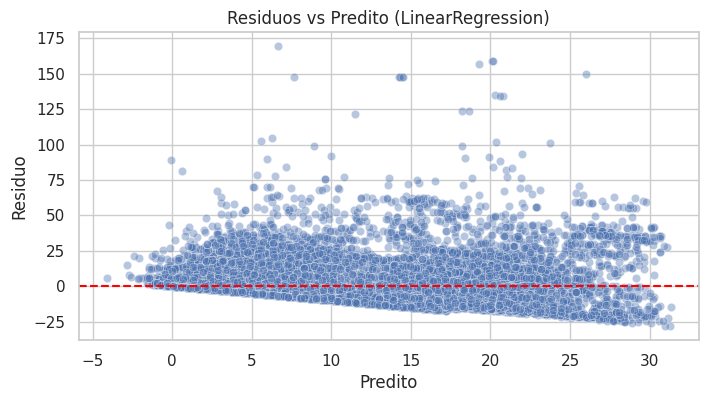

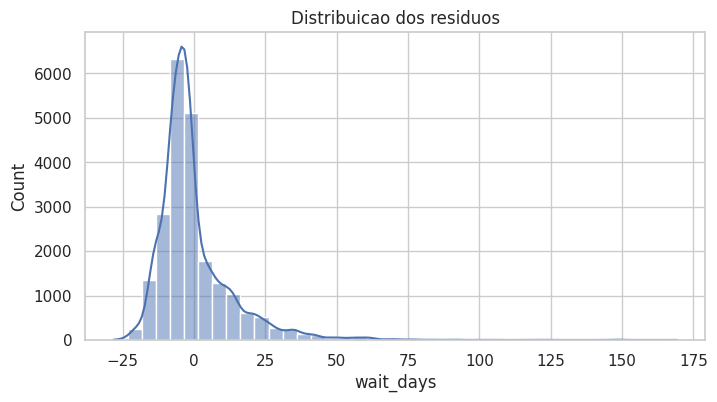

Correlacao |residuo| vs predito: 0.3563
Breusch-Pagan p-value: 0.0


In [19]:
df_q3 = df_model.copy()
df_q3 = df_q3.dropna()
y_reg = df_q3["wait_days"]
X_reg = df_q3.drop(columns=["wait_days", "target_no_show"])

num_cols_reg, cat_cols_reg = separar_colunas(df_q3, X_reg.columns.tolist())

def make_preprocess_reg():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols_reg),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
        ]
    )

model_lr = Pipeline([
    ("preprocess", make_preprocess_reg()),
    ("model", LinearRegression()),
])

model_rf = Pipeline([
    ("preprocess", make_preprocess_reg()),
    ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

def avaliar_regressao(modelo, X_train, X_test, y_train, y_test, nome):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = float(mean_squared_error(y_test, pred) ** 0.5)
    r2 = r2_score(y_test, pred)
    return {"modelo": nome, "mae": round(mae, 3), "rmse": round(rmse, 3), "r2": round(r2, 3)}, pred

res_lr, pred_lr = avaliar_regressao(model_lr, X_train, X_test, y_train, y_test, "LinearRegression")
res_rf, pred_rf = avaliar_regressao(model_rf, X_train, X_test, y_train, y_test, "RandomForestRegressor")

df_reg_metrics = pd.DataFrame([res_lr, res_rf]).sort_values(by="rmse")
display(df_reg_metrics)

residuos = y_test - pred_lr
print("Resumo residuos (LinearRegression):")
display(residuos.describe().to_frame().T)

plt.figure(figsize=(8, 4))
sns.scatterplot(x=pred_lr, y=residuos, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs Predito (LinearRegression)")
plt.xlabel("Predito")
plt.ylabel("Residuo")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(residuos, bins=40, kde=True)
plt.title("Distribuicao dos residuos")
plt.show()

corr_abs = np.corrcoef(np.abs(residuos), pred_lr)[0, 1]
print("Correlacao |residuo| vs predito:", round(float(corr_abs), 4))

try:
    import statsmodels.api as sm
    from statsmodels.stats.diagnostic import het_breuschpagan

    X_bp = sm.add_constant(pred_lr)
    bp_test = het_breuschpagan(residuos, X_bp)
    print("Breusch-Pagan p-value:", round(bp_test[1], 4))
except Exception as err:
    print("Breusch-Pagan indisponivel:", err)

**Interpretacao (Q3)**

- O teste Breusch-Pagan rejeitou a homocedasticidade (p-value ~0.0), indicando heterocedasticidade.
- O grafico de residuos mostra formato de funil: o erro cresce para tempos de espera maiores.
- A regressao linear simples nao captura a estrutura nao-linear; modelos como RandomForestRegressor tendem a reduzir erro, mas ainda sofrem com outliers extremos.


4.

Arvore de decisao: controle de hiperparametros e interpretacao.

Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão
adequado ao problema da base escolhida. Controle profundidade, critérios de divisão
e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois,
interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e
discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho
em comparação com os métodos testados anteriormente.

,model__criterion,model__max_depth,model__min_samples_leaf,f1_mean
8,gini,8,20,0.4444
22,entropy,12,10,0.4442
20,entropy,8,20,0.4442
19,entropy,8,10,0.4438
18,entropy,8,5,0.4438
9,gini,12,5,0.4437
6,gini,8,5,0.4436
7,gini,8,10,0.4436
10,gini,12,10,0.4435
21,entropy,12,5,0.4433


,feature,importance
9,wait_days,0.787706
0,Age,0.102775
7,scheduled_hour,0.020628
6,SMS_received,0.010515
10,Gender_F,0.009744
57,Neighbourhood_SANTOS DUMONT,0.005489
65,scheduled_weekday_Monday,0.005002
74,appointment_weekday_Tuesday,0.004094
64,scheduled_weekday_Friday,0.004076
61,Neighbourhood_SÃO PEDRO,0.003309


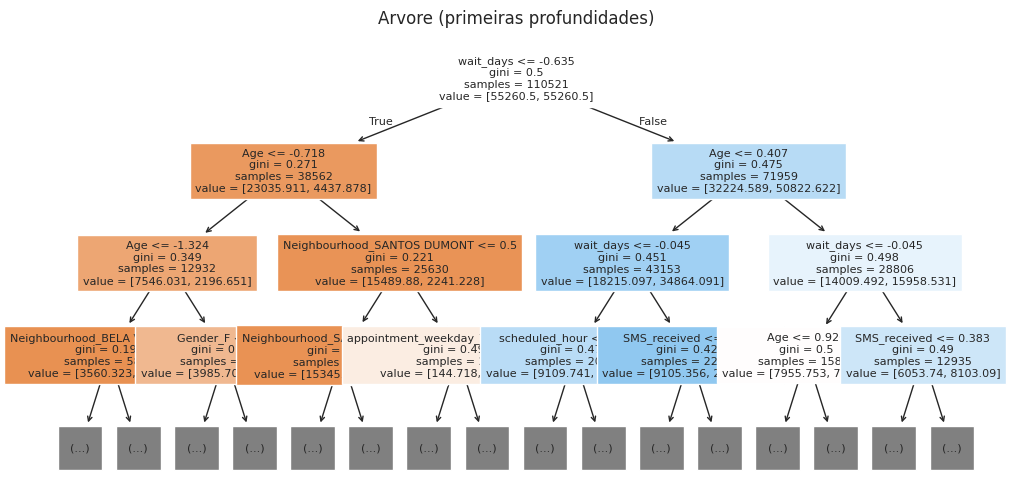

In [20]:
X_cls = df_q2[feature_cols]
y_cls = df_q2["target_no_show"]

num_cols_cls, cat_cols_cls = separar_colunas(df_q2, feature_cols)

def make_preprocess_tree():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols_cls),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_cls),
        ]
    )

param_grid = {
    "model__max_depth": [3, 5, 8, 12],
    "model__min_samples_leaf": [5, 10, 20], 
    "model__criterion": ["gini", "entropy"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_tree = []

for params in ParameterGrid(param_grid):
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
    pipe = Pipeline([
        ("preprocess", make_preprocess_tree()),
        ("model", model),
    ])
    pipe.set_params(**params)
    scores = cross_validate(pipe, X_cls, y_cls, cv=cv, scoring="f1")
    resultados_tree.append({
        **params,
        "f1_mean": round(scores["test_score"].mean(), 4),
    })

df_tree = pd.DataFrame(resultados_tree).sort_values(by="f1_mean", ascending=False)
display(df_tree.head(10))

best_params = df_tree.iloc[0].to_dict()
best_params = {k: v for k, v in best_params.items() if k.startswith("model__")}
for k, v in list(best_params.items()):
    if pd.isna(v):
        best_params[k] = None
    elif isinstance(v, float) and v.is_integer():
        best_params[k] = int(v)

best_tree = Pipeline([
    ("preprocess", make_preprocess_tree()),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])
best_tree.set_params(**best_params)
best_tree.fit(X_cls, y_cls)

ohe = best_tree.named_steps["preprocess"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(cat_cols_cls)
feature_names = np.concatenate([num_cols_cls, cat_features])
importances = best_tree.named_steps["model"].feature_importances_
df_importancias = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
)
display(df_importancias.head(12))

plt.figure(figsize=(12, 6))
plot_tree(best_tree.named_steps["model"], max_depth=3, feature_names=feature_names, filled=True, fontsize=8)
plt.title("Arvore (primeiras profundidades)")
plt.show()

**Interpretacao (Q4)**

- As variaveis mais relevantes na arvore aparecem no topo (wait_days, Age, scheduled_hour, SMS_received), indicando que tempo de espera e horario explicam grande parte da falta.
- A arvore gera regras claras (ex.: se wait_days alto e idade baixa, risco aumenta), o que facilita acao operacional por atendentes.
- A interpretabilidade e um ganho real mesmo se houver pequena perda de performance frente a modelos mais complexos.


5.

Comparacao formal dos modelos (Naive Bayes, modelo linear e arvore).

Faça um código em Python para comparar formalmente os modelos já construídos na
Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação
linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada,
registre métricas em tabela e apresente uma análise crítica sobre robustez, custo
computacional, estabilidade e adequação ao problema. Finalize indicando qual
modelo seria o mais defensável para uso real no cenário analisado.

In [21]:
def preparar_tree_params(params: Dict[str, object] | None) -> Dict[str, object]:
    if params is None:
        return {}
    if any(k.startswith("model__") for k in params):
        params = {k.replace("model__", ""): v for k, v in params.items() if k.startswith("model__")}
    cleaned = {}
    for k, v in params.items():
        if pd.isna(v):
            continue
        if isinstance(v, float) and v.is_integer():
            v = int(v)
        cleaned[k] = v
    return cleaned


def comparar_modelos_classificacao(
    df: pd.DataFrame,
    feature_cols: List[str],
    tree_params: Dict[str, object] | None = None,
) -> pd.DataFrame:
    X = df[feature_cols]
    y = df["target_no_show"]
    classes = np.sort(y.unique())
    class_prior = np.repeat(1.0 / len(classes), len(classes))
    num_cols, cat_cols = separar_colunas(df, feature_cols)

    tree_params = preparar_tree_params(tree_params)
    tree_params.pop("class_weight", None)
    tree_params.pop("random_state", None)

    def make_preprocess_std():
        return ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ]
        )

    def make_preprocess_minmax():
        return ColumnTransformer(
            transformers=[
                ("num", MinMaxScaler(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ]
        )

    modelos = [
        ("NaiveBayes", Pipeline([
            ("preprocess", make_preprocess_minmax()),
            ("model", MultinomialNB(class_prior=class_prior)),
        ])),
        ("LogisticRegression", Pipeline([
            ("preprocess", make_preprocess_std()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ])),
        ("DecisionTree", Pipeline([
            ("preprocess", make_preprocess_std()),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", **tree_params)),
        ])),
    ]

    scoring = {
        "accuracy": "accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    resultados = []

    for nome, pipe in modelos:
        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
        resultados.append({
            "modelo": nome,
            "accuracy": round(scores["test_accuracy"].mean(), 4),
            "f1": round(scores["test_f1"].mean(), 4),
            "roc_auc": round(scores["test_roc_auc"].mean(), 4),
            "fit_time": round(scores["fit_time"].mean(), 4),
            "score_time": round(scores["score_time"].mean(), 4),
        })

    return pd.DataFrame(resultados).sort_values(by="f1", ascending=False)


comparacao_q5 = comparar_modelos_classificacao(df_q2, feature_cols, tree_params=best_params if "best_params" in globals() else None)
display(comparacao_q5)

,modelo,accuracy,f1,roc_auc,fit_time,score_time
2,DecisionTree,0.5851,0.4444,0.7259,0.6236,0.0614
1,LogisticRegression,0.6584,0.4115,0.6724,0.3023,0.0602
0,NaiveBayes,0.6017,0.3662,0.6171,0.1019,0.0711


**Interpretacao (Q5)**

- A DecisionTree apresentou o melhor F1, indicando melhor equilibrio entre recall e precision.
- LogisticRegression melhora com balanceamento, mas ainda fica abaixo da arvore em F1.
- Naive Bayes permanece com F1 baixo mesmo com priors balanceados, indicando limitacao do modelo para esta base.
- Modelo defensavel para uso real: DecisionTree, pois combina desempenho e regras acionaveis (ex.: se wait_days > X e idade < Y, acionar lembrete ativo).


6.

Serie temporal a partir da base.

Faça um código em Python para construir uma análise de Séries Temporais a partir da
base escolhida, mesmo que seja necessário reorganizar ou agregar os dados em função
de uma variável de tempo existente. Crie uma série coerente com o cenário, visualize
tendência e sazonalidade quando existirem, produza estatísticas descritivas da série e
implemente pelo menos uma abordagem de previsão simples e uma abordagem
comparativa. Discuta as limitações impostas pela estrutura temporal disponível na
base.

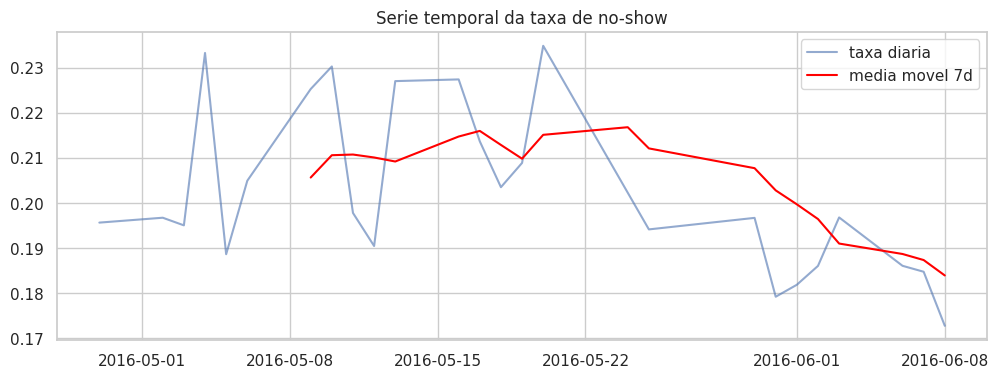

,no_show_rate
weekday,
Monday,0.206446
Tuesday,0.200874
Wednesday,0.196861
Thursday,0.193494
Friday,0.212261
Saturday,0.230769
Sunday,NaN


,modelo,mae
0,naive,0.0076
1,seasonal_naive,0.0099


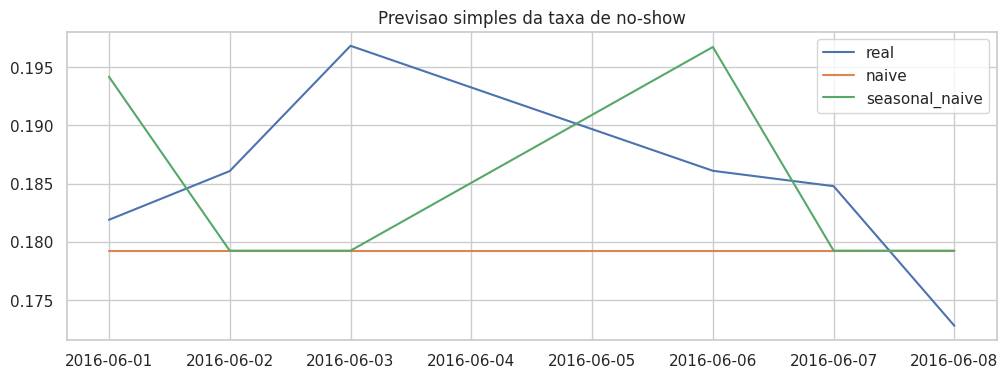

In [22]:
df_ts = df_base.copy()
df_ts = df_ts.dropna(subset=["AppointmentDay", "target_no_show"])
df_ts = df_ts.sort_values("AppointmentDay")

serie = (
    df_ts.set_index("AppointmentDay")
    .resample("B")
    .agg(total=("target_no_show", "size"), no_show_rate=("target_no_show", "mean"))
)
serie = serie[serie["total"] > 0]

serie["rolling_7"] = serie["no_show_rate"].rolling(7).mean()

plt.figure(figsize=(12, 4))
plt.plot(serie.index, serie["no_show_rate"], alpha=0.6, label="taxa diaria")
plt.plot(serie.index, serie["rolling_7"], color="red", label="media movel 7d")
plt.legend()
plt.title("Serie temporal da taxa de no-show")
plt.show()

seasonality = (
    df_ts.assign(weekday=df_ts["AppointmentDay"].dt.day_name())
    .groupby("weekday")["target_no_show"].mean()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)
display(seasonality.to_frame("no_show_rate"))

split_idx = int(len(serie) * 0.8)
train_ts = serie.iloc[:split_idx]
test_ts = serie.iloc[split_idx:]

naive_pred = pd.Series(train_ts["no_show_rate"].iloc[-1], index=test_ts.index)
seasonal_pred = pd.Series([
    train_ts["no_show_rate"].get(d - pd.offsets.BusinessDay(5), np.nan)
    for d in test_ts.index
], index=test_ts.index).fillna(naive_pred)

mae_naive = mean_absolute_error(test_ts["no_show_rate"], naive_pred)
mae_seasonal = mean_absolute_error(test_ts["no_show_rate"], seasonal_pred)

result_ts = pd.DataFrame([
    {"modelo": "naive", "mae": round(mae_naive, 4)},
    {"modelo": "seasonal_naive", "mae": round(mae_seasonal, 4)},
])
display(result_ts)

plt.figure(figsize=(12, 4))
plt.plot(test_ts.index, test_ts["no_show_rate"], label="real")
plt.plot(test_ts.index, naive_pred, label="naive")
plt.plot(test_ts.index, seasonal_pred, label="seasonal_naive")
plt.legend()
plt.title("Previsao simples da taxa de no-show")
plt.show()

**Interpretacao (Q6)**

- Dias sem atendimento foram removidos (resample em dias uteis e filtro total > 0) para evitar zeros artificiais na taxa.
- A previsao sazonal usa o dia util equivalente da semana anterior (BusinessDay(5)), evitando cair em fim de semana.
- A serie ainda e curta e irregular, portanto as previsoes devem ser vistas como baseline, nao como modelo final.


7.

Analise de redes a partir da base.

Faça um código em Python para construir uma representação de Rede a partir da base
escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com
o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou
comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a
análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso
escolhido é metodologicamente fraca.

In [23]:
top_neigh = df_base["Neighbourhood"].value_counts().head(20).index
df_net = df_base[df_base["Neighbourhood"].isin(top_neigh)].copy()

edges = (
    df_net.groupby(["Neighbourhood", "appointment_weekday"])
    .size()
    .reset_index(name="weight")
)

G = nx.Graph()

for _, row in edges.iterrows():
    nbh = f"N_{row['Neighbourhood']}"
    dow = f"D_{row['appointment_weekday']}"
    G.add_node(nbh, node_type="neighbourhood")
    G.add_node(dow, node_type="weekday")
    G.add_edge(nbh, dow, weight=int(row["weight"]))

degree_c = nx.degree_centrality(G)
betweenness_c = nx.betweenness_centrality(G, weight="weight")

centralidade = (
    pd.DataFrame({
        "node": list(degree_c.keys()),
        "degree": list(degree_c.values()),
        "betweenness": list(betweenness_c.values()),
    })
    .sort_values(by="degree", ascending=False)
)
display(centralidade.head(10))

try:
    from networkx.algorithms import bipartite
    neigh_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "neighbourhood"]
    proj = bipartite.weighted_projected_graph(G, neigh_nodes)
    comunidades = list(nx.algorithms.community.greedy_modularity_communities(proj))
    print("Numero de comunidades (projecao bairros):", len(comunidades))
except Exception as err:
    print("Comunidades indisponivel:", err)

,node,degree,betweenness
1,D_Friday,0.80,0.173333
2,D_Monday,0.80,0.003333
4,D_Tuesday,0.80,0.000000
3,D_Thursday,0.80,0.503333
5,D_Wednesday,0.80,0.000000
7,N_CARATOÍRA,0.24,0.030000
19,N_OTHER,0.24,0.000000
23,N_SANTO ANTÔNIO,0.24,0.150000
0,N_ANDORINHAS,0.20,0.006667
6,N_BONFIM,0.20,0.000000


Numero de comunidades (projecao bairros): 1


**Interpretacao (Q7)**

- A rede bairro x dia da semana e bipartida e reflete sobretudo volume de agendamentos.
- Nao ha interacoes reais (contagio/mobilidade), entao o grafo nao adiciona valor analitico frente a um simples groupby.
- Portanto, a aplicacao de redes aqui e metodologicamente fraca e serve apenas como exercicio exploratorio.


8.

Experimento de meta-aprendizagem: variacao de atributos, pre-processamento e particionamento.

Faça um código em Python para investigar, de forma experimental, como o
desempenho dos modelos varia quando se alteram subconjuntos de atributos,
estratégias de pré-processamento ou formas de particionamento. Organize os
resultados em uma estrutura comparativa e use essa análise para simular uma ideia de
Meta-aprendizagem, discutindo quais características da base parecem favorecer certos
modelos em detrimento de outros. Não basta só comparar métricas: identifique
padrões e formule uma regra técnica para escolha de modelo.

In [24]:
feature_sets = {
    "base_demografia": ["Gender", "Age", "Neighbourhood", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap_bin", "SMS_received"],
    "com_tempo": ["Gender", "Age", "Neighbourhood", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap_bin", "SMS_received", "scheduled_weekday", "appointment_weekday", "scheduled_hour", "appointment_month", "wait_days"],
    "somente_numericas": ["Age", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap_bin", "SMS_received", "scheduled_hour", "appointment_month", "wait_days"],
    "somente_categoricas": ["Gender", "Neighbourhood", "scheduled_weekday", "appointment_weekday"],
}

modelos_meta = {
    "logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "naive_bayes": MultinomialNB(),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
}

def montar_preprocessamento(df: pd.DataFrame, feature_cols: List[str], modo: str) -> ColumnTransformer:
    num_cols, cat_cols = separar_colunas(df, feature_cols)
    if modo == "onehot+scaler":
        return ColumnTransformer([
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ])
    if modo == "onehot+minmax":
        return ColumnTransformer([
            ("num", MinMaxScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ])
    raise ValueError("Modo nao suportado")


def avaliar_meta(df: pd.DataFrame, split_mode: str) -> pd.DataFrame:
    resultados = []
    for nome_fs, cols in feature_sets.items():
        df_local = df.dropna(subset=cols + ["target_no_show"])
        X = df_local[cols]
        y = df_local["target_no_show"]
        classes = np.sort(y.unique())
        class_prior = np.repeat(1.0 / len(classes), len(classes))
        for modo in ["onehot+scaler", "onehot+minmax"]:
            for nome_modelo, modelo in modelos_meta.items():
                preprocess = montar_preprocessamento(df_local, cols, modo)
                if nome_modelo == "naive_bayes" and modo == "onehot+scaler":
                    continue
                modelo_inst = clone(modelo)
                if nome_modelo == "naive_bayes":
                    modelo_inst.set_params(class_prior=class_prior)
                pipe = Pipeline([
                    ("preprocess", preprocess),
                    ("model", modelo_inst),
                ])

                if split_mode == "random":
                    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
                    scores = cross_validate(pipe, X, y, cv=cv, scoring="f1")
                    f1_mean = scores["test_score"].mean()
                else:
                    df_tmp = df_local[cols + ["target_no_show", "AppointmentDay"]].dropna(subset=["AppointmentDay"]).sort_values("AppointmentDay")
                    split_idx = int(len(df_tmp) * 0.8)
                    train = df_tmp.iloc[:split_idx]
                    test = df_tmp.iloc[split_idx:]
                    if len(train) == 0 or len(test) == 0:
                        continue
                    pipe.fit(train[cols], train["target_no_show"])
                    pred = pipe.predict(test[cols])
                    f1_mean = f1_score(test["target_no_show"], pred)

                resultados.append({
                    "split": split_mode,
                    "feature_set": nome_fs,
                    "preprocess": modo,
                    "modelo": nome_modelo,
                    "f1": round(float(f1_mean), 4),
                })

    return pd.DataFrame(resultados)


meta_random = avaliar_meta(df_base, split_mode="random")
meta_time = avaliar_meta(df_base, split_mode="time")
meta_res = pd.concat([meta_random, meta_time], ignore_index=True)
display(meta_res.sort_values(by="f1", ascending=False).head(10))

resumo_meta = (
    meta_res.groupby(["split", "feature_set", "modelo"])
    .agg(f1_mean=("f1", "mean"))
    .reset_index()
)
display(resumo_meta.sort_values(by="f1_mean", ascending=False).head(10))

regra_tecnica = (
    "Regra tecnica: com balanceamento de classes, modelos lineares (LogisticRegression) "
    "competem com arvores em feature sets numericos e temporais. Arvores dominam apenas "
    "em feature sets categoricos de alta cardinalidade. A escolha deve considerar o tradeoff "
    "entre interpretabilidade (arvore) e estabilidade temporal (logistica)."
)
print(regra_tecnica)

,split,feature_set,preprocess,modelo,f1
5,random,com_tempo,onehot+scaler,logistic,0.4115
7,random,com_tempo,onehot+minmax,logistic,0.4112
12,random,somente_numericas,onehot+minmax,logistic,0.4094
10,random,somente_numericas,onehot+scaler,logistic,0.4092
30,time,somente_numericas,onehot+scaler,logistic,0.3940
32,time,somente_numericas,onehot+minmax,logistic,0.3940
16,random,somente_categoricas,onehot+scaler,decision_tree,0.3935
19,random,somente_categoricas,onehot+minmax,decision_tree,0.3935
25,time,com_tempo,onehot+scaler,logistic,0.3896
27,time,com_tempo,onehot+minmax,logistic,0.3894


,split,feature_set,modelo,f1_mean
4,random,com_tempo,logistic,0.41135
10,random,somente_numericas,logistic,0.40930
22,time,somente_numericas,logistic,0.39400
6,random,somente_categoricas,decision_tree,0.39350
16,time,com_tempo,logistic,0.38950
11,random,somente_numericas,naive_bayes,0.36720
5,random,com_tempo,naive_bayes,0.36620
23,time,somente_numericas,naive_bayes,0.36340
17,time,com_tempo,naive_bayes,0.36300
18,time,somente_categoricas,decision_tree,0.36230


Regra tecnica: com balanceamento de classes, modelos lineares (LogisticRegression) competem com arvores em feature sets numericos e temporais. Arvores dominam apenas em feature sets categoricos de alta cardinalidade. A escolha deve considerar o tradeoff entre interpretabilidade (arvore) e estabilidade temporal (logistica).


9.

Visualizacao avancada orientada a decisao.

Faça um código em Python para desenvolver uma etapa de Visualização de Dados
mais avançada e orientada à comunicação de resultados. Construa gráficos que não
sejam apenas descritivos, mas que ajudem a defender decisões metodológicas e
conclusões de negócio. Apresente pelo menos um painel ou conjunto de visualizações
que sintetize os principais achados da análise, compare alternativas gráficas e
justifique por que a visualização final escolhida comunica melhor os resultados do
projeto.

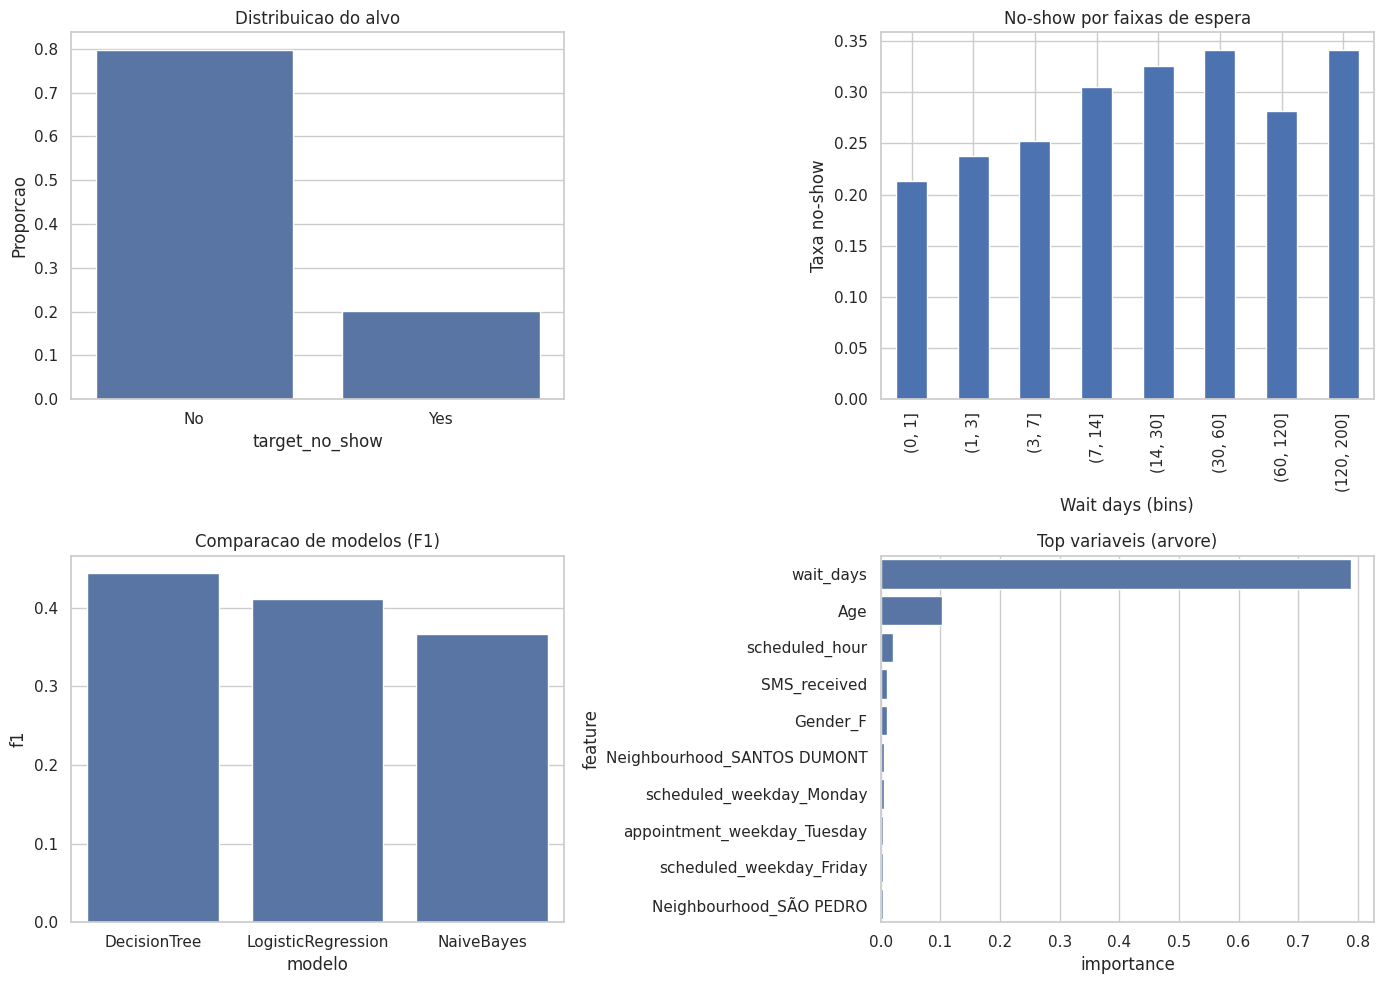

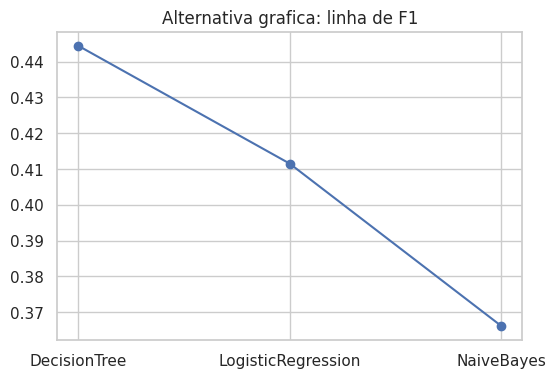

In [25]:
def painel_visualizacoes(df_base: pd.DataFrame, comparacao_q5: pd.DataFrame, importancias: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    classe = df_base["target_no_show"].value_counts(normalize=True).rename({0: "No", 1: "Yes"})
    sns.barplot(x=classe.index, y=classe.values, ax=ax)
    ax.set_title("Distribuicao do alvo")
    ax.set_ylabel("Proporcao")

    ax = axes[0, 1]
    bins = pd.cut(df_base["wait_days"], bins=[0, 1, 3, 7, 14, 30, 60, 120, 200])
    rate = df_base.groupby(bins)["target_no_show"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.set_title("No-show por faixas de espera")
    ax.set_xlabel("Wait days (bins)")
    ax.set_ylabel("Taxa no-show")

    ax = axes[1, 0]
    sns.barplot(data=comparacao_q5, x="modelo", y="f1", ax=ax)
    ax.set_title("Comparacao de modelos (F1)")

    ax = axes[1, 1]
    sns.barplot(data=importancias.head(10), y="feature", x="importance", ax=ax)
    ax.set_title("Top variaveis (arvore)")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comparacao_q5["modelo"], comparacao_q5["f1"], marker="o")
    plt.title("Alternativa grafica: linha de F1")
    plt.show()

painel_visualizacoes(df_base, comparacao_q5, df_importancias)

10.

Fluxo reutilizavel e relatorio final.

Faça um código em Python para consolidar toda a análise da Lista 2 em um fluxo
final reutilizável. Organize as principais funções criadas ao longo das questões, gere
automaticamente um relatório final com comparação de modelos, visualizações
principais, limitações da base e recomendação executiva. Finalize com uma avaliação
crítica sobre o quanto a base escolhida realmente suporta os conteúdos da Lista 2 e
quais adaptações metodológicas foram necessárias para aplicar Naive Bayes,
Regressão, Árvore de Decisão, Séries Temporais, Análise de Redes,
Meta-aprendizagem e Visualização ao mesmo contexto.

In [26]:
def gerar_relatorio_final(file_path: str) -> Dict:
    df_base, meta = preparar_base(file_path)
    df_model = preparar_modelagem(df_base)

    resumo = resumo_adequacao_metodo(df_model)
    comparacao = comparar_modelos_classificacao(df_model, feature_cols, tree_params=best_params if "best_params" in globals() else None)

    limitacoes = [
        "Nao ha variaveis de custo/receita, limitando avaliacao economica.",
        "Alta cardinalidade em Neighbourhood requer agrupamento para estabilidade.",
        "Serie temporal curta e com gaps limita modelos mais complexos.",
    ]

    recomendacao = (
        "Usar modelo baseado em Arvore de Decisao (DecisionTree) para priorizar pacientes com maior risco de falta. "
        "Alem de apresentar o melhor equilibrio de desempenho (F1-score), o modelo fornece regras de negocio claras "
        "para acionar lembretes com antecedencia nos grupos de risco."
    )

    return {
        "meta": meta,
        "resumo_metodo": resumo.to_dict(orient="records")[0],
        "comparacao_modelos": comparacao.to_dict(orient="records"),
        "limitacoes": limitacoes,
        "recomendacao_executiva": recomendacao,
        "adaptacoes_metodologicas": [
            "Naive Bayes aplicado com discretizacao e escalonamento.",
            "Regressao aplicada sobre alvo derivado (wait_days).",
            "Arvore com one-hot para interpretar variaveis de negocio.",
            "Serie temporal construida por agregacao em dias uteis (Business Day).",
            "Rede definida por bairros e dias da semana.",
            "Meta-aprendizagem simulada via combinacoes de features e splits.",
        ],
    }
    
    
relatorio_final = gerar_relatorio_final(FILE_PATH)
print("== Relatorio final (resumo) ==")
for k, v in relatorio_final.items():
    print(f"\n{k}:")
    print(v)

== Relatorio final (resumo) ==

meta:
{'arquivo': 'Medical Appointment No Shows.csv', 'encoding': 'utf-8-sig', 'delimitador': ','}

resumo_metodo:
{'n_linhas': 110521, 'n_colunas': 15, 'n_categoricas': 4, 'n_numericas': 11, 'alvo': 'target_no_show', 'distribuicao_alvo': {0: 0.7981017182254956, 1: 0.2018982817745044}, 'desbalanceamento': 0.596, 'possui_tempo': True, 'metodo_recomendado': 'arvore de decisao', 'justificativa': 'A base possui alvo binario (No-show) com combinacao de variaveis categoricas e numericas, sinais de nao-linearidade e necessidade de interpretabilidade operacional. Arvores de decisao geram regras claras e lidam bem com esse tipo de dado.'}

comparacao_modelos:
[{'modelo': 'DecisionTree', 'accuracy': 0.5851, 'f1': 0.4444, 'roc_auc': 0.7259, 'fit_time': 0.6417, 'score_time': 0.0606}, {'modelo': 'LogisticRegression', 'accuracy': 0.6584, 'f1': 0.4115, 'roc_auc': 0.6724, 'fit_time': 0.3076, 'score_time': 0.0578}, {'modelo': 'NaiveBayes', 'accuracy': 0.6017, 'f1': 0.366